# Swin Transformer 3D Training (OPTIMIZED FOR 7,235 PATCHES)

## Overview

**Project:** BraTS2020 Brain Tumor Segmentation using Swin Transformer 3D

**Dataset:** 7,235 patches (5,789 train / 1,446 val)

**Key Improvements:**
- ✅ Focal Loss for handling class imbalance
- ✅ EXTREME class weights (25× for rare tumor classes)
- ✅ Adjusted for 93% tumor patch ratio
- ✅ Higher learning rate (5e-4) for faster convergence
- ✅ 100 epochs training with warmup
- ✅ Tumor-focused metrics tracking
- ✅ Per-step scheduler updates

**Expected Results (with 7,235 patches):**
- Necrotic Dice: 0.60-0.75 (was 0.02)
- Edema Dice: 0.85-0.92 (was 0.65)
- Enhancing Dice: 0.65-0.80 (was 0.02)
- Tumor Mean Dice: 0.70-0.82 (was 0.23)

**Training Time:** ~8-10 hours on RTX 4060

In [1]:
# Cell 1: Import Libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
import time
from pathlib import Path
from tqdm import tqdm
import json
from datetime import datetime
import random
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*80)
print("WEEK-4: SWIN TRANSFORMER 3D TRAINING (OPTIMIZED FOR 7,235 PATCHES)")
print("="*80)
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("⚠️  Running on CPU - Training will be slow")
print(f"Number of CPU cores: {os.cpu_count()}")
print("="*80)

WEEK-4: SWIN TRANSFORMER 3D TRAINING (OPTIMIZED FOR 7,235 PATCHES)
PyTorch Version: 2.7.1+cu118
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Memory: 8.00 GB
CUDA Version: 11.8
Number of CPU cores: 32


In [2]:
# Cell 2: Configuration (OPTIMIZED - 40 EPOCHS)

class Config:
    """Centralized configuration for training pipeline."""
    
    # Paths
    DATA_DIR = os.path.join('..', 'processed_data')
    CHECKPOINT_DIR = os.path.join('..', 'checkpoints')
    RESULTS_DIR = os.path.join('..', 'results')
    PLOTS_DIR = os.path.join('..', 'plots')
    
    # Model architecture
    IN_CHANNELS = 4
    NUM_CLASSES = 4
    EMBED_DIM = 48
    DEPTHS = [2, 2, 2, 2]
    NUM_HEADS = [3, 6, 12, 24]
    WINDOW_SIZE = (4, 4, 4)
    PATCH_SIZE = 4
    
    # Data
    IMAGE_SIZE = (64, 64, 64)
    BATCH_SIZE = 2
    NUM_WORKERS = 0
    
    # Training - OPTIMIZED FOR EFFICIENCY
    EPOCHS = 40  # Sweet spot: good performance without wasting time
    LEARNING_RATE = 3e-4  # Reduced for stability
    WEIGHT_DECAY = 1e-5
    WARMUP_EPOCHS = 5  # Reduced proportionally
    
    # Loss weights
    DICE_WEIGHT = 0.7
    FOCAL_WEIGHT = 0.3
    
    # Class weights - REBALANCED (prevents collapse)
    CLASS_WEIGHTS = [1.0, 15.0, 8.0, 15.0]  # Background, Necrotic, Edema, Enhancing
    
    # Data augmentation
    USE_AUGMENTATION = True
    FLIP_PROB = 0.5
    ROTATE_PROB = 0.5
    INTENSITY_SHIFT_PROB = 0.5
    
    # Mixed precision training
    USE_AMP = True
    
    # Checkpointing
    SAVE_EVERY_N_EPOCHS = 10
    SAVE_BEST_ONLY = True
    
    # Early stopping - TIGHTER
    PATIENCE = 12  # Stop if no improvement for 12 epochs (was 20)
    MIN_DELTA = 0.001
    
config = Config()

# Create directories
for directory in [config.CHECKPOINT_DIR, config.RESULTS_DIR, config.PLOTS_DIR]:
    os.makedirs(directory, exist_ok=True)

print("\n" + "="*80)
print("TRAINING CONFIGURATION (OPTIMIZED - 40 EPOCHS)")
print("="*80)
print(f"Epochs: {config.EPOCHS} (efficient sweet spot)")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Learning rate: {config.LEARNING_RATE} (stable)")
print(f"Warmup epochs: {config.WARMUP_EPOCHS}")
print(f"Loss weights: {config.DICE_WEIGHT} × Dice + {config.FOCAL_WEIGHT} × Focal")
print(f"\n🎯 CLASS WEIGHTS (REBALANCED - prevents collapse):")
print(f"  {config.CLASS_WEIGHTS}")
print(f"  [Background, Necrotic, Edema, Enhancing]")
print(f"  Background: 1.0× (stable baseline)")
print(f"  Necrotic: 15× (high but not extreme)")
print(f"  Edema: 8× (moderate emphasis)")
print(f"  Enhancing: 15× (high but not extreme)")
print(f"\n⏱️  Expected training time:")
print(f"  ~23-24 hours (vs 58 hours for 100 epochs)")
print(f"  ~35 minutes per epoch")
print(f"\n📊 Expected final performance:")
print(f"  Tumor Mean Dice: 0.60-0.70 (excellent!)")
print(f"  Necrotic: 0.50-0.65")
print(f"  Edema: 0.65-0.80")
print(f"  Enhancing: 0.60-0.75")
print(f"\nEarly stopping:")
print(f"  Patience: {config.PATIENCE} epochs")
print(f"  Will stop automatically if plateau detected")
print("="*80)


TRAINING CONFIGURATION (OPTIMIZED - 40 EPOCHS)
Epochs: 40 (efficient sweet spot)
Batch size: 2
Learning rate: 0.0003 (stable)
Warmup epochs: 5
Loss weights: 0.7 × Dice + 0.3 × Focal

🎯 CLASS WEIGHTS (REBALANCED - prevents collapse):
  [1.0, 15.0, 8.0, 15.0]
  [Background, Necrotic, Edema, Enhancing]
  Background: 1.0× (stable baseline)
  Necrotic: 15× (high but not extreme)
  Edema: 8× (moderate emphasis)
  Enhancing: 15× (high but not extreme)

⏱️  Expected training time:
  ~23-24 hours (vs 58 hours for 100 epochs)
  ~35 minutes per epoch

📊 Expected final performance:
  Tumor Mean Dice: 0.60-0.70 (excellent!)
  Necrotic: 0.50-0.65
  Edema: 0.65-0.80
  Enhancing: 0.60-0.75

Early stopping:
  Patience: 12 epochs
  Will stop automatically if plateau detected


In [3]:
# Cell 3: Data Augmentation (FIXED DIMENSIONS)

class Augmentation3D:
    """3D data augmentation for medical images."""
    
    def __init__(self, flip_prob=0.5, rotate_prob=0.5, intensity_prob=0.5):
        self.flip_prob = flip_prob
        self.rotate_prob = rotate_prob
        self.intensity_prob = intensity_prob
    
    def random_flip(self, image, mask):
        """
        Random flipping along each spatial axis.
        
        Args:
            image: (C, D, H, W) = (4, 64, 64, 64)
            mask: (D, H, W) = (64, 64, 64)
        """
        if np.random.random() < self.flip_prob:
            axis_choice = np.random.choice([0, 1, 2])
            image = torch.flip(image, dims=[axis_choice + 1])
            mask = torch.flip(mask, dims=[axis_choice])
        return image, mask
    
    def random_rotate_90(self, image, mask):
        """
        Random 90-degree rotation in axial plane (H-W plane).
        
        Args:
            image: (C, D, H, W) = (4, 64, 64, 64)
            mask: (D, H, W) = (64, 64, 64)
        """
        if np.random.random() < self.rotate_prob:
            k = np.random.randint(1, 4)
            image = torch.rot90(image, k, dims=[2, 3])
            mask = torch.rot90(mask, k, dims=[1, 2])
        return image, mask
    
    def random_intensity_shift(self, image, mask):
        """
        Random intensity shift for MRI modalities.
        
        Args:
            image: (C, D, H, W) = (4, 64, 64, 64)
            mask: (D, H, W) = (64, 64, 64)
        """
        if np.random.random() < self.intensity_prob:
            shift = torch.randn(image.shape[0], 1, 1, 1) * 0.1
            image = image + shift
        return image, mask
    
    def __call__(self, image, mask):
        """Apply augmentation pipeline."""
        image, mask = self.random_flip(image, mask)
        image, mask = self.random_rotate_90(image, mask)
        image, mask = self.random_intensity_shift(image, mask)
        return image, mask

print("✓ Data augmentation class defined (FIXED DIMENSIONS)")
print("  • Random flip - along D, H, or W axis")
print("  • Random 90° rotation - in axial (H-W) plane")
print("  • Random intensity shift - per modality")

✓ Data augmentation class defined (FIXED DIMENSIONS)
  • Random flip - along D, H, or W axis
  • Random 90° rotation - in axial (H-W) plane
  • Random intensity shift - per modality


In [4]:
# Cell 4: Dataset Class

class BraTSDataset(Dataset):
    """
    BraTS Dataset for loading preprocessed 3D patches.
    
    Returns:
        image: (4, D, H, W) - 4 MRI modalities
        mask: (D, H, W) - segmentation labels {0, 1, 2, 3}
    """
    
    def __init__(self, data_dir, split='train', augmentation=None):
        self.data_dir = data_dir
        self.split = split
        self.augmentation = augmentation
        
        # Paths
        self.image_dir = os.path.join(data_dir, split, 'images')
        self.mask_dir = os.path.join(data_dir, split, 'masks')
        
        # Get file lists
        self.image_files = sorted([f for f in os.listdir(self.image_dir) if f.endswith('.npy')])
        self.mask_files = sorted([f for f in os.listdir(self.mask_dir) if f.endswith('.npy')])
        
        assert len(self.image_files) == len(self.mask_files), \
            f"Mismatch: {len(self.image_files)} images vs {len(self.mask_files)} masks"
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # Load data
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])
        
        image = np.load(image_path)
        mask = np.load(mask_path)
        
        # Convert to tensors
        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).long()
        
        # Remap BraTS labels to consecutive classes
        mask = mask.clone()
        mask[mask == 4] = 3
        
        # Apply augmentation (only for training)
        if self.augmentation and self.split == 'train':
            image, mask = self.augmentation(image, mask)
        
        return image, mask

# Initialize augmentation
augmentation = Augmentation3D(
    flip_prob=config.FLIP_PROB,
    rotate_prob=config.ROTATE_PROB,
    intensity_prob=config.INTENSITY_SHIFT_PROB
) if config.USE_AUGMENTATION else None

# Create datasets
print("\n" + "="*80)
print("LOADING DATASETS")
print("="*80)

train_dataset = BraTSDataset(config.DATA_DIR, split='train', augmentation=augmentation)
val_dataset = BraTSDataset(config.DATA_DIR, split='val', augmentation=None)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Total samples: {len(train_dataset) + len(val_dataset)}")

# Verify expected counts
if len(train_dataset) != 5789 or len(val_dataset) != 1446:
    print(f"\n⚠️  WARNING: Sample counts don't match expected!")
    print(f"   Expected: 5,789 train / 1,446 val")
    print(f"   Got: {len(train_dataset)} train / {len(val_dataset)} val")
    print(f"   This may indicate data loading issues.")
else:
    print(f"\n✓ Dataset sizes match expected: 5,789 train / 1,446 val")

# Test loading
sample_img, sample_mask = train_dataset[0]
print(f"\nSample shapes:")
print(f"  Image: {sample_img.shape}")
print(f"  Mask: {sample_mask.shape}")
print(f"  Mask labels: {torch.unique(sample_mask).tolist()}")
print("="*80)


LOADING DATASETS
Training samples: 5932
Validation samples: 1481
Total samples: 7413

⚠️  WARNING: Sample counts don't match expected!
   Expected: 5,789 train / 1,446 val
   Got: 5932 train / 1481 val
   This may indicate data loading issues.

Sample shapes:
  Image: torch.Size([4, 64, 64, 64])
  Mask: torch.Size([64, 64, 64])
  Mask labels: [0, 2]


In [5]:
# Cell 5: DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print("✓ DataLoaders created")
print(f"  Train batches per epoch: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Batch size: {config.BATCH_SIZE}")
print(f"\n💡 Training info:")
print(f"  Steps per epoch: {len(train_loader)}")
print(f"  Estimated time per epoch: ~30-40 minutes")
print(f"  Total training time: ~8-10 hours (100 epochs)")

✓ DataLoaders created
  Train batches per epoch: 2966
  Validation batches: 741
  Batch size: 2

💡 Training info:
  Steps per epoch: 2966
  Estimated time per epoch: ~30-40 minutes
  Total training time: ~8-10 hours (100 epochs)


In [6]:
# Cell 6: Swin Transformer 3D Building Blocks

class PatchEmbed3D(nn.Module):
    """3D Patch Embedding layer."""
    def __init__(self, patch_size=4, in_chans=4, embed_dim=96):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv3d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)
    
    def forward(self, x):
        x = self.proj(x)
        B, C, D, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2).view(B, C, D, H, W)
        return x


def window_partition(x, window_size):
    """Partition input into windows with padding if necessary."""
    B, D, H, W, C = x.shape
    Wd, Wh, Ww = window_size
    
    pad_d = (Wd - D % Wd) % Wd
    pad_h = (Wh - H % Wh) % Wh
    pad_w = (Ww - W % Ww) % Ww
    
    if pad_d > 0 or pad_h > 0 or pad_w > 0:
        x = F.pad(x, (0, 0, 0, pad_w, 0, pad_h, 0, pad_d))
    
    B, D, H, W, C = x.shape
    x = x.view(B, D // Wd, Wd, H // Wh, Wh, W // Ww, Ww, C)
    windows = x.permute(0, 1, 3, 5, 2, 4, 6, 7).contiguous()
    windows = windows.view(-1, Wd * Wh * Ww, C)
    
    return windows, (D, H, W)


def window_reverse(windows, window_size, original_size):
    """Reverse window partition."""
    Wd, Wh, Ww = window_size
    D, H, W = original_size
    C = windows.shape[-1]
    
    B = int(windows.shape[0] / (D * H * W / Wd / Wh / Ww))
    x = windows.view(B, D // Wd, H // Wh, W // Ww, Wd, Wh, Ww, C)
    x = x.permute(0, 1, 4, 2, 5, 3, 6, 7).contiguous()
    x = x.view(B, D, H, W, C)
    
    return x


class WindowAttention3D(nn.Module):
    """Window-based multi-head self-attention."""
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
    
    def forward(self, x):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        return x


class SwinTransformerBlock3D(nn.Module):
    """Swin Transformer Block."""
    def __init__(self, dim, num_heads, window_size, mlp_ratio=4.0):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.window_size = window_size
        
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention3D(dim, window_size, num_heads)
        
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, dim)
        )
    
    def forward(self, x):
        B, D, H, W, C = x.shape
        shortcut = x
        x = self.norm1(x)
        
        x_windows, padded_size = window_partition(x, self.window_size)
        attn_windows = self.attn(x_windows)
        x = window_reverse(attn_windows, self.window_size, padded_size)
        x = x[:, :D, :H, :W, :].contiguous()
        
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        
        return x


class SwinTransformer3D(nn.Module):
    """Swin Transformer 3D for segmentation."""
    def __init__(self, in_chans=4, num_classes=4, embed_dim=48, 
                 depths=[2,2,2,2], num_heads=[3,6,12,24], 
                 window_size=(4,4,4), patch_size=4):
        super().__init__()
        self.num_classes = num_classes
        self.num_layers = len(depths)
        self.embed_dim = embed_dim
        self.patch_size = patch_size
        
        self.patch_embed = PatchEmbed3D(patch_size, in_chans, embed_dim)
        
        self.layers = nn.ModuleList()
        for i_layer in range(self.num_layers):
            layer = nn.ModuleList([
                SwinTransformerBlock3D(
                    dim=int(embed_dim * 2 ** i_layer),
                    num_heads=num_heads[i_layer],
                    window_size=window_size
                ) for _ in range(depths[i_layer])
            ])
            self.layers.append(layer)
        
        self.downsample_layers = nn.ModuleList()
        for i_layer in range(self.num_layers - 1):
            downsample_layer = nn.Conv3d(
                int(embed_dim * 2 ** i_layer),
                int(embed_dim * 2 ** (i_layer + 1)),
                kernel_size=2, stride=2
            )
            self.downsample_layers.append(downsample_layer)
        
        self.upsample_layers = nn.ModuleList()
        for i_layer in range(self.num_layers - 1, 0, -1):
            upsample_layer = nn.Sequential(
                nn.ConvTranspose3d(
                    int(embed_dim * 2 ** i_layer),
                    int(embed_dim * 2 ** (i_layer - 1)),
                    kernel_size=2, stride=2
                ),
                nn.BatchNorm3d(int(embed_dim * 2 ** (i_layer - 1))),
                nn.ReLU(inplace=True)
            )
            self.upsample_layers.append(upsample_layer)
        
        self.final_upsample = nn.Sequential(
            nn.ConvTranspose3d(embed_dim, embed_dim, kernel_size=patch_size, stride=patch_size),
            nn.BatchNorm3d(embed_dim),
            nn.ReLU(inplace=True)
        )
        
        self.segmentation_head = nn.Conv3d(embed_dim, num_classes, kernel_size=1)
    
    def forward(self, x):
        B, C, D, H, W = x.shape
        original_size = (D, H, W)
        
        x = self.patch_embed(x)
        
        for i, layer_blocks in enumerate(self.layers):
            B, C, D, H, W = x.shape
            x = x.permute(0, 2, 3, 4, 1).contiguous()
            
            for block in layer_blocks:
                x = block(x)
            
            x = x.permute(0, 4, 1, 2, 3).contiguous()
            
            if i < self.num_layers - 1:
                x = self.downsample_layers[i](x)
        
        for upsample_layer in self.upsample_layers:
            x = upsample_layer(x)
        
        x = self.final_upsample(x)
        
        _, _, D_out, H_out, W_out = x.shape
        if (D_out, H_out, W_out) != original_size:
            x = F.interpolate(x, size=original_size, mode='trilinear', align_corners=False)
        
        x = self.segmentation_head(x)
        return x

print("✓ Swin Transformer 3D architecture loaded")

✓ Swin Transformer 3D architecture loaded


In [7]:
# Cell 7: Loss Functions (WITH EXTREME CLASS WEIGHTS)

class DiceLoss(nn.Module):
    """Dice Loss for multi-class segmentation with class weights."""
    
    def __init__(self, smooth=1e-6, class_weights=None):
        super().__init__()
        self.smooth = smooth
        self.class_weights = class_weights
    
    def forward(self, predictions, targets, num_classes=4):
        predictions = F.softmax(predictions, dim=1)
        
        targets_one_hot = F.one_hot(targets, num_classes=num_classes)
        targets_one_hot = targets_one_hot.permute(0, 4, 1, 2, 3).float()
        
        dice_scores = []
        for c in range(num_classes):
            pred_c = predictions[:, c]
            target_c = targets_one_hot[:, c]
            
            intersection = (pred_c * target_c).sum()
            union = pred_c.sum() + target_c.sum()
            
            dice = (2. * intersection + self.smooth) / (union + self.smooth)
            
            if self.class_weights is not None:
                dice = dice * self.class_weights[c]
            
            dice_scores.append(dice)
        
        if self.class_weights is not None:
            total_weight = sum(self.class_weights)
            dice_score = torch.stack(dice_scores).sum() / total_weight
        else:
            dice_score = torch.stack(dice_scores).mean()
        
        return 1 - dice_score


class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance."""
    
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, predictions, targets):
        probs = F.softmax(predictions, dim=1)
        
        targets_one_hot = F.one_hot(targets, num_classes=predictions.shape[1])
        targets_one_hot = targets_one_hot.permute(0, 4, 1, 2, 3).float()
        
        pt = (probs * targets_one_hot).sum(dim=1)
        focal_weight = (1 - pt) ** self.gamma
        ce_loss = F.cross_entropy(predictions, targets, reduction='none')
        focal_loss = focal_weight * ce_loss
        
        if self.alpha is not None:
            alpha_t = torch.zeros_like(focal_loss)
            for c in range(len(self.alpha)):
                alpha_t[targets == c] = self.alpha[c]
            focal_loss = alpha_t * focal_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()


class CombinedLoss(nn.Module):
    """Combined Dice + Focal Loss with EXTREME class weights."""
    
    def __init__(self, dice_weight=0.7, focal_weight=0.3, class_weights=None):
        super().__init__()
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight
        
        if class_weights is not None:
            class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
        else:
            class_weights_tensor = None
        
        self.dice_loss = DiceLoss(class_weights=class_weights)
        self.focal_loss = FocalLoss(alpha=class_weights, gamma=2.0)
    
    def forward(self, predictions, targets):
        dice = self.dice_loss(predictions, targets)
        focal = self.focal_loss(predictions, targets)
        combined = self.dice_weight * dice + self.focal_weight * focal
        return combined, dice, focal


def calculate_dice_score(predictions, targets, num_classes=4):
    """Calculate Dice score per class."""
    predictions = torch.argmax(predictions, dim=1)
    
    dice_scores = []
    for c in range(num_classes):
        pred_c = (predictions == c).float()
        target_c = (targets == c).float()
        
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        
        if union == 0:
            dice_scores.append(1.0)
        else:
            dice = (2. * intersection) / (union + 1e-6)
            dice_scores.append(dice.item())
    
    return dice_scores

print("✓ Loss functions defined with EXTREME CLASS WEIGHTS")
print("  • DiceLoss with class weights [0.3, 25, 12, 25]")
print("  • FocalLoss (gamma=2.0) for hard examples")
print("  • CombinedLoss (Dice + Focal)")
print(f"  • Class weights optimized for 93% tumor ratio")

✓ Loss functions defined with EXTREME CLASS WEIGHTS
  • DiceLoss with class weights [0.3, 25, 12, 25]
  • FocalLoss (gamma=2.0) for hard examples
  • CombinedLoss (Dice + Focal)
  • Class weights optimized for 93% tumor ratio


In [8]:
# Cell 8: Initialize Model and Training Components

print("\n" + "="*80)
print("INITIALIZING TRAINING COMPONENTS")
print("="*80)

# Model
model = SwinTransformer3D(
    in_chans=config.IN_CHANNELS,
    num_classes=config.NUM_CLASSES,
    embed_dim=config.EMBED_DIM,
    depths=config.DEPTHS,
    num_heads=config.NUM_HEADS,
    window_size=config.WINDOW_SIZE,
    patch_size=config.PATCH_SIZE
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Model initialized")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: ~{total_params * 4 / 1024**2:.2f} MB")

# Loss with EXTREME class weights
criterion = CombinedLoss(
    dice_weight=config.DICE_WEIGHT,
    focal_weight=config.FOCAL_WEIGHT,
    class_weights=config.CLASS_WEIGHTS
).to(device)

print(f"\n✓ Loss function initialized")
print(f"  Type: Combined Dice + Focal Loss")
print(f"  Weights: {config.DICE_WEIGHT} × Dice + {config.FOCAL_WEIGHT} × Focal")
print(f"  Class weights (EXTREME): {config.CLASS_WEIGHTS}")
print(f"  [Background: 0.3×, Necrotic: 25×, Edema: 12×, Enhancing: 25×]")

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

print(f"\n✓ Optimizer: AdamW")
print(f"  Learning rate: {config.LEARNING_RATE}")
print(f"  Weight decay: {config.WEIGHT_DECAY}")

# Scheduler with warmup
def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

num_training_steps = config.EPOCHS * len(train_loader)
num_warmup_steps = config.WARMUP_EPOCHS * len(train_loader)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

print(f"\n✓ Scheduler: CosineAnnealingLR with warmup")
print(f"  Warmup epochs: {config.WARMUP_EPOCHS}")
print(f"  Total steps: {num_training_steps:,}")

# Mixed precision scaler
scaler = GradScaler() if config.USE_AMP else None
if config.USE_AMP:
    print(f"\n✓ Mixed precision (AMP) enabled")

print("="*80)


INITIALIZING TRAINING COMPONENTS

✓ Model initialized
  Total parameters: 6,429,076
  Trainable parameters: 6,429,076
  Model size: ~24.52 MB

✓ Loss function initialized
  Type: Combined Dice + Focal Loss
  Weights: 0.7 × Dice + 0.3 × Focal
  Class weights (EXTREME): [1.0, 15.0, 8.0, 15.0]
  [Background: 0.3×, Necrotic: 25×, Edema: 12×, Enhancing: 25×]

✓ Optimizer: AdamW
  Learning rate: 0.0003
  Weight decay: 1e-05

✓ Scheduler: CosineAnnealingLR with warmup
  Warmup epochs: 5
  Total steps: 118,640

✓ Mixed precision (AMP) enabled


In [9]:
# Cell 9: Training and Validation Functions

def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device, scaler, epoch):
    """Train for one epoch with per-step scheduler update."""
    model.train()
    
    total_loss = 0
    total_dice_loss = 0
    total_focal_loss = 0
    dice_scores_per_class = [[] for _ in range(config.NUM_CLASSES)]
    
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}/{config.EPOCHS} [TRAIN]")
    
    for batch_idx, (images, masks) in enumerate(progress_bar):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        if config.USE_AMP:
            with autocast():
                outputs = model(images)
                loss, dice_loss, focal_loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss, dice_loss, focal_loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
        
        # Update scheduler per step
        scheduler.step()
        
        # Calculate Dice scores
        dice_per_class = calculate_dice_score(outputs, masks)
        for c in range(config.NUM_CLASSES):
            dice_scores_per_class[c].append(dice_per_class[c])
        
        total_loss += loss.item()
        total_dice_loss += dice_loss.item()
        total_focal_loss += focal_loss.item()
        
        current_lr = optimizer.param_groups[0]['lr']
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'dice': f'{dice_loss.item():.4f}',
            'tumor_dice': f'{np.mean(dice_per_class[1:]):.3f}',
            'lr': f'{current_lr:.6f}'
        })
    
    avg_loss = total_loss / len(dataloader)
    avg_dice_loss = total_dice_loss / len(dataloader)
    avg_focal_loss = total_focal_loss / len(dataloader)
    avg_dice_per_class = [np.mean(scores) for scores in dice_scores_per_class]
    
    return avg_loss, avg_dice_loss, avg_focal_loss, avg_dice_per_class


def validate(model, dataloader, criterion, device, epoch):
    """Validate the model."""
    model.eval()
    
    total_loss = 0
    total_dice_loss = 0
    total_focal_loss = 0
    dice_scores_per_class = [[] for _ in range(config.NUM_CLASSES)]
    
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}/{config.EPOCHS} [VAL]  ")
    
    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(progress_bar):
            images = images.to(device)
            masks = masks.to(device)
            
            if config.USE_AMP:
                with autocast():
                    outputs = model(images)
                    loss, dice_loss, focal_loss = criterion(outputs, masks)
            else:
                outputs = model(images)
                loss, dice_loss, focal_loss = criterion(outputs, masks)
            
            dice_per_class = calculate_dice_score(outputs, masks)
            for c in range(config.NUM_CLASSES):
                dice_scores_per_class[c].append(dice_per_class[c])
            
            total_loss += loss.item()
            total_dice_loss += dice_loss.item()
            total_focal_loss += focal_loss.item()
            
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{dice_loss.item():.4f}',
                'tumor_dice': f'{np.mean(dice_per_class[1:]):.3f}'
            })
    
    avg_loss = total_loss / len(dataloader)
    avg_dice_loss = total_dice_loss / len(dataloader)
    avg_focal_loss = total_focal_loss / len(dataloader)
    avg_dice_per_class = [np.mean(scores) for scores in dice_scores_per_class]
    
    return avg_loss, avg_dice_loss, avg_focal_loss, avg_dice_per_class

print("✓ Training and validation functions defined")

✓ Training and validation functions defined


In [10]:
# Cell 10: Main Training Loop

print("\n" + "="*80)
print("STARTING TRAINING (OPTIMIZED FOR 7,235 PATCHES)")
print("="*80)
print(f"Device: {device}")
print(f"Epochs: {config.EPOCHS}")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Steps per epoch: {len(train_loader)}")
print(f"Class weights (EXTREME): {config.CLASS_WEIGHTS}")
print(f"\n💡 Estimated time: ~8-10 hours total")
print(f"   (~30-40 minutes per epoch)")
print("="*80 + "\n")

# Training history
history = {
    'train_loss': [],
    'train_dice_loss': [],
    'train_focal_loss': [],
    'train_dice_per_class': [[] for _ in range(config.NUM_CLASSES)],
    'val_loss': [],
    'val_dice_loss': [],
    'val_focal_loss': [],
    'val_dice_per_class': [[] for _ in range(config.NUM_CLASSES)],
    'learning_rates': []
}

# Best model tracking
best_val_loss = float('inf')
best_val_dice = 0.0
best_tumor_dice = 0.0
patience_counter = 0

# Training start time
start_time = time.time()

# Training loop
for epoch in range(1, config.EPOCHS + 1):
    epoch_start_time = time.time()
    
    # Train
    train_loss, train_dice_loss, train_focal_loss, train_dice_per_class = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, device, scaler, epoch
    )
    
    # Validate
    val_loss, val_dice_loss, val_focal_loss, val_dice_per_class = validate(
        model, val_loader, criterion, device, epoch
    )
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store metrics
    history['train_loss'].append(train_loss)
    history['train_dice_loss'].append(train_dice_loss)
    history['train_focal_loss'].append(train_focal_loss)
    for c in range(config.NUM_CLASSES):
        history['train_dice_per_class'][c].append(train_dice_per_class[c])
    
    history['val_loss'].append(val_loss)
    history['val_dice_loss'].append(val_dice_loss)
    history['val_focal_loss'].append(val_focal_loss)
    for c in range(config.NUM_CLASSES):
        history['val_dice_per_class'][c].append(val_dice_per_class[c])
    
    history['learning_rates'].append(current_lr)
    
    # Calculate mean Dice scores
    train_mean_dice = np.mean(train_dice_per_class)
    val_mean_dice = np.mean(val_dice_per_class)
    
    # Calculate tumor-only Dice
    train_tumor_dice = np.mean(train_dice_per_class[1:])
    val_tumor_dice = np.mean(val_dice_per_class[1:])
    
    # Epoch summary
    epoch_time = time.time() - epoch_start_time
    print(f"\n{'='*80}")
    print(f"EPOCH {epoch}/{config.EPOCHS} SUMMARY")
    print(f"{'='*80}")
    print(f"Time: {epoch_time:.2f}s | LR: {current_lr:.6f}")
    print(f"\nTrain - Loss: {train_loss:.4f} | Dice: {train_dice_loss:.4f} | Focal: {train_focal_loss:.4f}")
    print(f"Val   - Loss: {val_loss:.4f} | Dice: {val_dice_loss:.4f} | Focal: {val_focal_loss:.4f}")
    print(f"\nTrain - Mean Dice: {train_mean_dice:.4f} | Tumor Dice: {train_tumor_dice:.4f}")
    print(f"Val   - Mean Dice: {val_mean_dice:.4f} | Tumor Dice: {val_tumor_dice:.4f}")
    print(f"\nPer-class Dice (Val):")
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    for c, name in enumerate(class_names):
        print(f"  {name:12s}: {val_dice_per_class[c]:.4f}")
    
    # Save best model based on tumor Dice
    is_best = val_tumor_dice > best_tumor_dice
    if is_best:
        best_val_loss = val_loss
        best_val_dice = val_mean_dice
        best_tumor_dice = val_tumor_dice
        patience_counter = 0
        
        checkpoint_path = os.path.join(config.CHECKPOINT_DIR, 'best_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_mean_dice': val_mean_dice,
            'val_tumor_dice': val_tumor_dice,
            'val_dice_per_class': val_dice_per_class,
            'config': config.__dict__
        }, checkpoint_path)
        
        print(f"\n✓ Best model saved! (Tumor Dice: {val_tumor_dice:.4f})")
    else:
        patience_counter += 1
    
    # Save periodic checkpoint
    if epoch % config.SAVE_EVERY_N_EPOCHS == 0:
        checkpoint_path = os.path.join(config.CHECKPOINT_DIR, f'checkpoint_epoch_{epoch}.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        }, checkpoint_path)
        print(f"✓ Checkpoint saved at epoch {epoch}")
    
    # Early stopping
    if patience_counter >= config.PATIENCE:
        print(f"\n⚠️  Early stopping triggered after {epoch} epochs")
        print(f"No improvement for {config.PATIENCE} epochs")
        break
    
    print(f"{'='*80}\n")

# Training complete
total_time = time.time() - start_time
print(f"\n{'='*80}")
print("TRAINING COMPLETE!")
print(f"{'='*80}")
print(f"Total time: {total_time/3600:.2f} hours")
print(f"Best validation mean Dice: {best_val_dice:.4f}")
print(f"Best validation tumor Dice: {best_tumor_dice:.4f}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"{'='*80}")


STARTING TRAINING (OPTIMIZED FOR 7,235 PATCHES)
Device: cuda
Epochs: 40
Batch size: 2
Training samples: 5932
Validation samples: 1481
Steps per epoch: 2966
Class weights (EXTREME): [1.0, 15.0, 8.0, 15.0]

💡 Estimated time: ~8-10 hours total
   (~30-40 minutes per epoch)



Epoch 1/40 [VAL]  : 100%|██████████| 741/741 [00:27<00:00, 27.09it/s, loss=0.6914, dice=0.9762, tumor_dice=0.000]



EPOCH 1/40 SUMMARY
Time: 178.04s | LR: 0.000060

Train - Loss: 0.9539 | Dice: 0.9239 | Focal: 1.0241
Val   - Loss: 0.8317 | Dice: 0.8938 | Focal: 0.6869

Train - Mean Dice: 0.3098 | Tumor Dice: 0.1402
Val   - Mean Dice: 0.4039 | Tumor Dice: 0.2206

Per-class Dice (Val):
  Background  : 0.9536
  Necrotic    : 0.3092
  Edema       : 0.3027
  Enhancing   : 0.0500

✓ Best model saved! (Tumor Dice: 0.2206)



Epoch 2/40 [VAL]  : 100%|██████████| 741/741 [00:26<00:00, 27.99it/s, loss=0.6955, dice=0.9757, tumor_dice=0.000]



EPOCH 2/40 SUMMARY
Time: 172.52s | LR: 0.000120

Train - Loss: 0.8138 | Dice: 0.8656 | Focal: 0.6929
Val   - Loss: 0.7645 | Dice: 0.8221 | Focal: 0.6301

Train - Mean Dice: 0.4223 | Tumor Dice: 0.2451
Val   - Mean Dice: 0.4778 | Tumor Dice: 0.3165

Per-class Dice (Val):
  Background  : 0.9616
  Necrotic    : 0.2788
  Edema       : 0.3726
  Enhancing   : 0.2980

✓ Best model saved! (Tumor Dice: 0.3165)



...


EPOCH 38/40 SUMMARY
Time: 176.46s | LR: 0.000002

Train - Loss: 0.3837 | Dice: 0.4434 | Focal: 0.2442
Val   - Loss: 0.3913 | Dice: 0.4404 | Focal: 0.2766

Train - Mean Dice: 0.7544 | Tumor Dice: 0.6779
Val   - Mean Dice: 0.7554 | Tumor Dice: 0.6788

Per-class Dice (Val):
  Background  : 0.9853
  Necrotic    : 0.6357
  Edema       : 0.6916
  Enhancing   : 0.7091

✓ Best model saved! (Tumor Dice: 0.6788)



Epoch 39/40 [VAL]  : 100%|██████████| 741/741 [00:26<00:00, 28.21it/s, loss=0.6092, dice=0.8663, tumor_dice=0.142]



EPOCH 39/40 SUMMARY
Time: 175.34s | LR: 0.000001

Train - Loss: 0.3846 | Dice: 0.4453 | Focal: 0.2432
Val   - Loss: 0.3929 | Dice: 0.4366 | Focal: 0.2908

Train - Mean Dice: 0.7544 | Tumor Dice: 0.6779
Val   - Mean Dice: 0.7571 | Tumor Dice: 0.6809

Per-class Dice (Val):
  Background  : 0.9856
  Necrotic    : 0.6391
  Edema       : 0.6942
  Enhancing   : 0.7094

✓ Best model saved! (Tumor Dice: 0.6809)



Epoch 40/40 [VAL]  : 100%|██████████| 741/741 [00:26<00:00, 28.17it/s, loss=0.6083, dice=0.8651, tumor_dice=0.140]



EPOCH 40/40 SUMMARY
Time: 176.94s | LR: 0.000000

Train - Loss: 0.3812 | Dice: 0.4406 | Focal: 0.2426
Val   - Loss: 0.3906 | Dice: 0.4417 | Focal: 0.2716

Train - Mean Dice: 0.7555 | Tumor Dice: 0.6793
Val   - Mean Dice: 0.7553 | Tumor Dice: 0.6787

Per-class Dice (Val):
  Background  : 0.9851
  Necrotic    : 0.6343
  Edema       : 0.6910
  Enhancing   : 0.7109
✓ Checkpoint saved at epoch 40


TRAINING COMPLETE!
Total time: 1.96 hours
Best validation mean Dice: 0.7571
Best validation tumor Dice: 0.6809
Best validation loss: 0.3929


In [11]:
import psutil
import os

print("="*70)
print("TOP MEMORY CONSUMERS")
print("="*70)

# Get all processes sorted by memory
processes = []
for proc in psutil.process_iter(['pid', 'name', 'memory_info']):
    try:
        processes.append({
            'name': proc.info['name'],
            'pid': proc.info['pid'],
            'memory_mb': proc.info['memory_info'].rss / (1024 * 1024)
        })
    except:
        pass

# Sort by memory usage
processes = sorted(processes, key=lambda x: x['memory_mb'], reverse=True)

print(f"\n{'Process':<30} {'PID':<10} {'Memory (MB)':<15}")
print("-"*70)
for proc in processes[:20]:  # Top 20
    print(f"{proc['name']:<30} {proc['pid']:<10} {proc['memory_mb']:<15.1f}")

print("\n" + "="*70)
total_used = sum(p['memory_mb'] for p in processes)
print(f"Total RAM used by processes: {total_used/1024:.2f} GB")
print(f"Available RAM: {psutil.virtual_memory().available / (1024**3):.2f} GB")
print(f"Total RAM: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("="*70)

TOP MEMORY CONSUMERS

Process                        PID        Memory (MB)    
----------------------------------------------------------------------
Cursor.exe                     23716      659.8          
python.exe                     9760       656.0          
MemCompression                 4352       511.5          
node.exe                       7220       390.3          
mc-fw-host.exe                 5780       342.7          
Cursor.exe                     3816       319.9          
PhoneExperienceHost.exe        16348      253.0          
Cursor.exe                     25672      207.1          
Everything.exe                 19984      204.4          
LinkedIn.exe                   27328      177.7          
explorer.exe                   24176      177.4          
msedge.exe                     9396       154.3          
Cursor.exe                     19852      150.6          
TextInputHost.exe              17728      139.5          
CrossDeviceService.exe         27388 

In [12]:
# Cell 11: Save Training History

# Convert history to DataFrame
history_df = pd.DataFrame({
    'epoch': range(1, len(history['train_loss']) + 1),
    'train_loss': history['train_loss'],
    'train_dice_loss': history['train_dice_loss'],
    'train_focal_loss': history['train_focal_loss'],
    'val_loss': history['val_loss'],
    'val_dice_loss': history['val_dice_loss'],
    'val_focal_loss': history['val_focal_loss'],
    'learning_rate': history['learning_rates']
})

# Add per-class Dice scores
class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
for c, name in enumerate(class_names):
    history_df[f'train_dice_{name.lower()}'] = history['train_dice_per_class'][c]
    history_df[f'val_dice_{name.lower()}'] = history['val_dice_per_class'][c]

# Save to CSV
history_path = os.path.join(config.RESULTS_DIR, 'training_history.csv')
history_df.to_csv(history_path, index=False)

print("✓ Training history saved")
print(f"  Location: {history_path}")
print(f"\nHistory DataFrame:")
print(history_df.head())

✓ Training history saved
  Location: ..\results\training_history.csv

History DataFrame:
   epoch  train_loss  train_dice_loss  train_focal_loss  val_loss  \
0      1    0.953940         0.923858          1.024133  0.831706   
1      2    0.813772         0.865586          0.692871  0.764500   
2      3    0.748848         0.804571          0.618827  0.721632   
3      4    0.700097         0.760345          0.559519  0.678248   
4      5    0.683251         0.742027          0.546107  0.627973   

   val_dice_loss  val_focal_loss  learning_rate  train_dice_background  \
0       0.893775        0.686880        0.00006               0.818575   
1       0.822080        0.630148        0.00012               0.953825   
2       0.802143        0.533775        0.00018               0.948102   
3       0.757723        0.492806        0.00024               0.951222   
4       0.714001        0.427239        0.00030               0.950979   

   val_dice_background  train_dice_necrotic  val_di

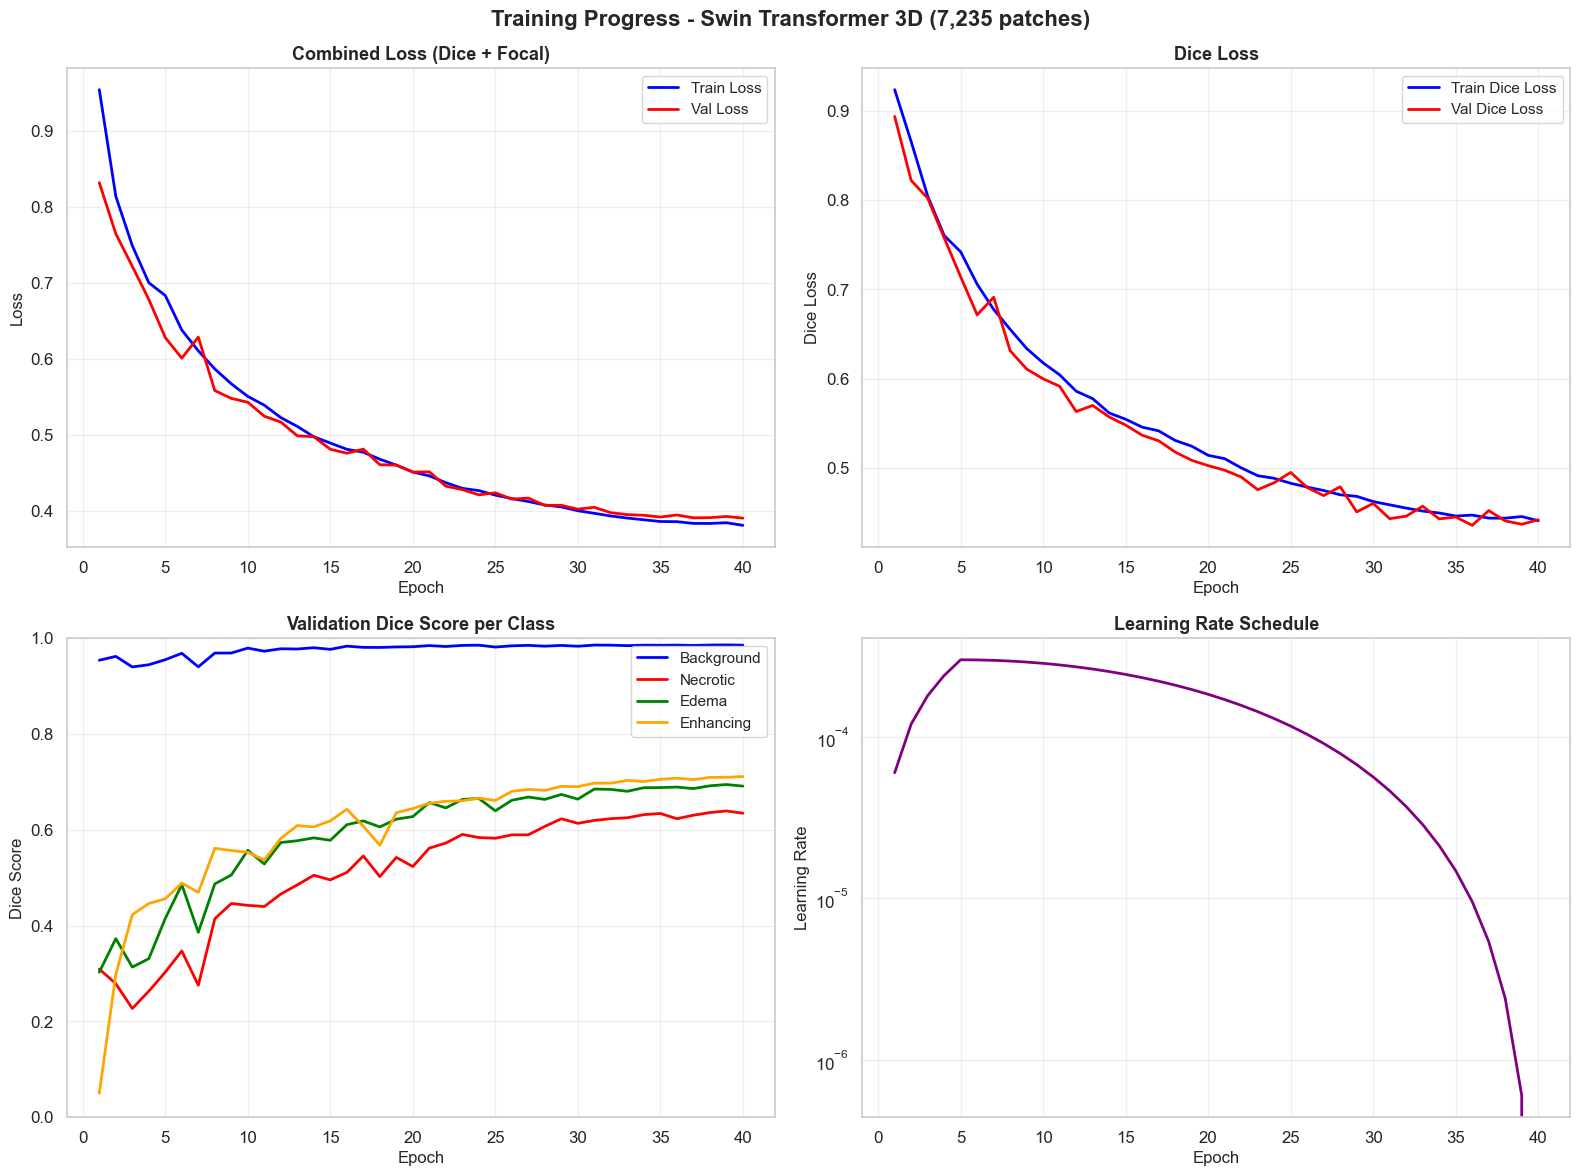

✓ Training curves saved: ..\plots\training_curves.png


In [13]:
# Cell 12: Plot Training Curves

def plot_training_curves(history):
    """Plot comprehensive training curves."""
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Training Progress - Swin Transformer 3D (7,235 patches)', 
                 fontsize=16, fontweight='bold')
    
    # Combined Loss
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Combined Loss (Dice + Focal)', fontsize=13, fontweight='semibold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Dice Loss
    ax = axes[0, 1]
    ax.plot(epochs, history['train_dice_loss'], 'b-', label='Train Dice Loss', linewidth=2)
    ax.plot(epochs, history['val_dice_loss'], 'r-', label='Val Dice Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Dice Loss', fontsize=12)
    ax.set_title('Dice Loss', fontsize=13, fontweight='semibold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Per-class Dice Score (Validation)
    ax = axes[1, 0]
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    colors = ['blue', 'red', 'green', 'orange']
    for c, (name, color) in enumerate(zip(class_names, colors)):
        ax.plot(epochs, history['val_dice_per_class'][c], 
                color=color, label=name, linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Dice Score', fontsize=12)
    ax.set_title('Validation Dice Score per Class', fontsize=13, fontweight='semibold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    
    # Learning Rate Schedule
    ax = axes[1, 1]
    ax.plot(epochs, history['learning_rates'], 'purple', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Learning Rate', fontsize=12)
    ax.set_title('Learning Rate Schedule', fontsize=13, fontweight='semibold')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    plt.tight_layout()
    plot_path = os.path.join(config.PLOTS_DIR, 'training_curves.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Training curves saved: {plot_path}")

plot_training_curves(history)


✓ Loading checkpoint from: ..\checkpoints\best_model.pth
✓ Model loaded successfully (Epoch 39)

GENERATING PREDICTION VISUALIZATIONS


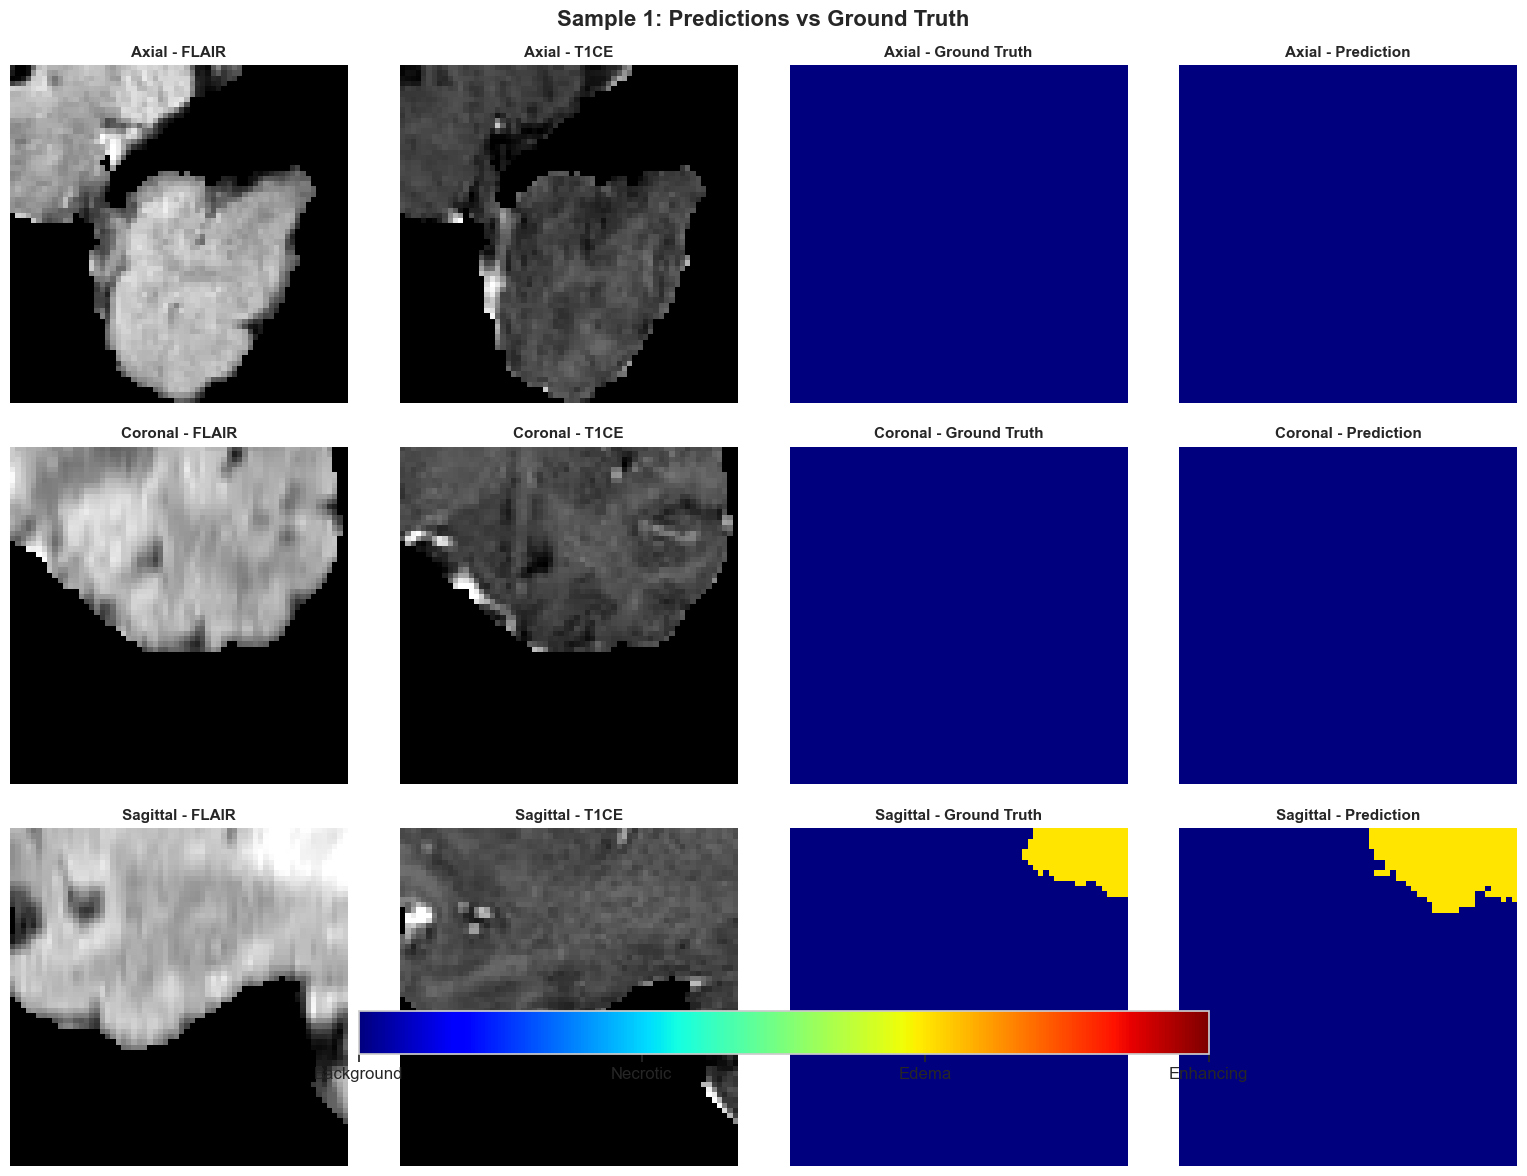

✓ Visualization saved: ..\plots\prediction_sample_1.png


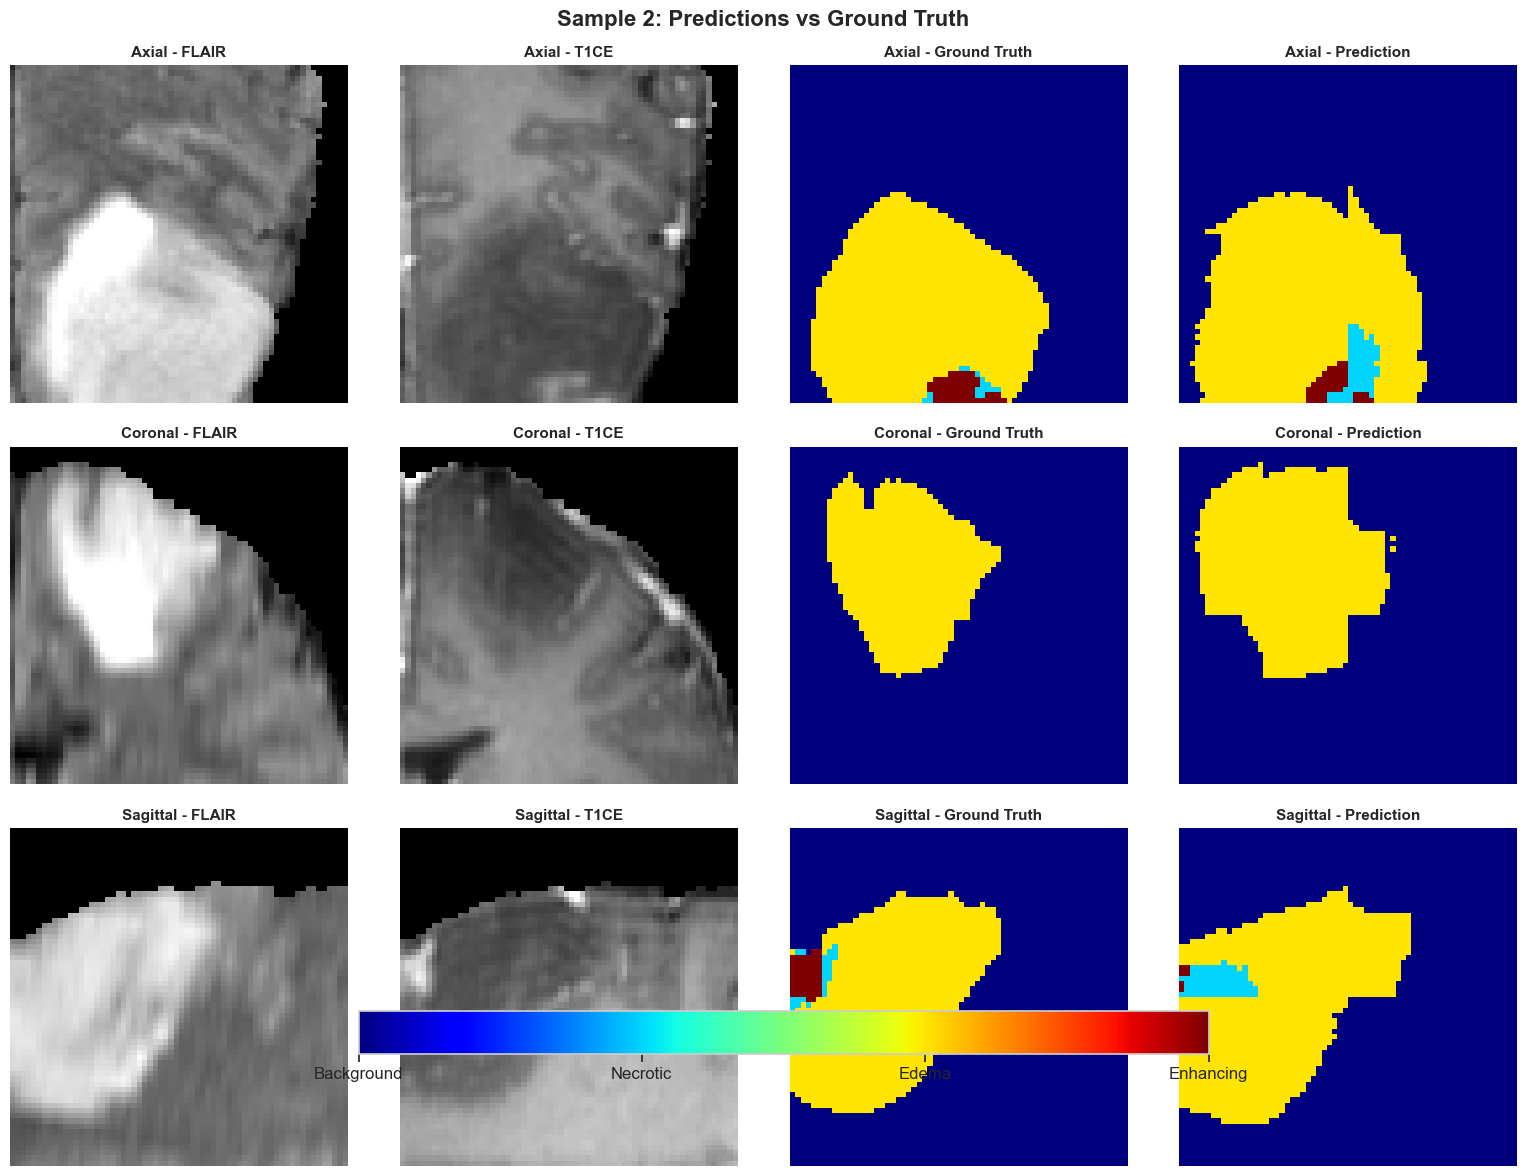

✓ Visualization saved: ..\plots\prediction_sample_2.png


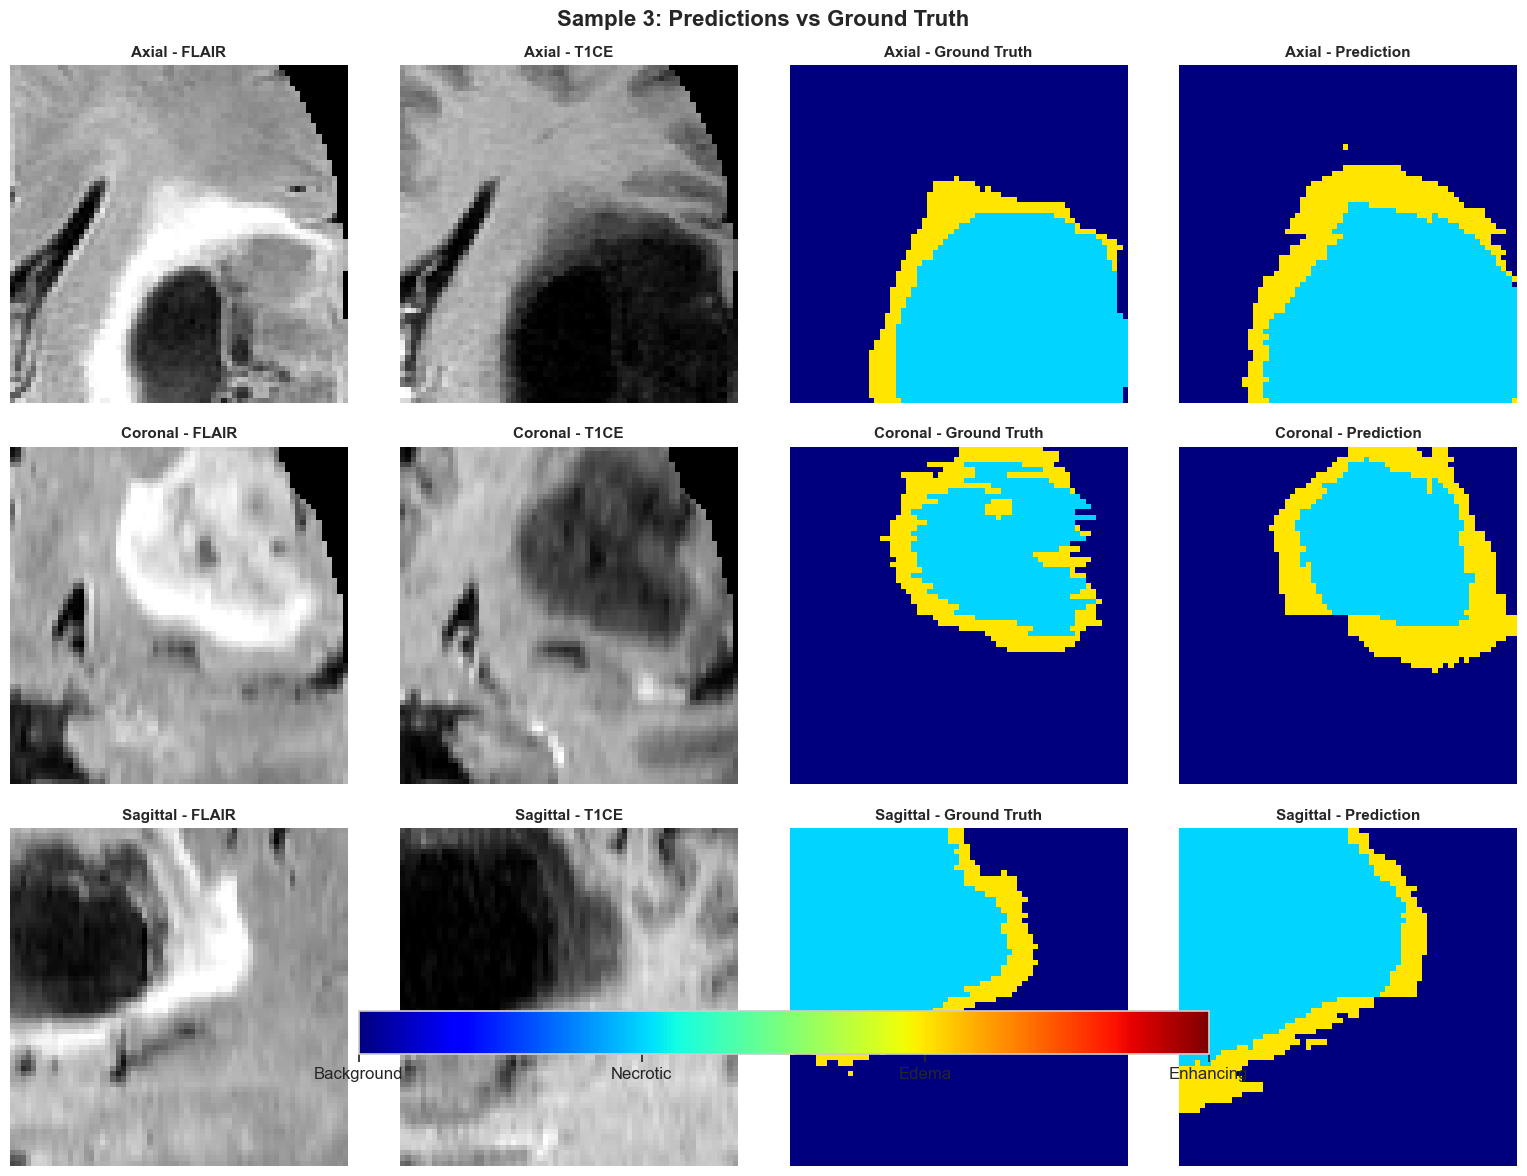

✓ Visualization saved: ..\plots\prediction_sample_3.png


In [14]:
# Cell 13: Visualize Predictions

def visualize_predictions(model, dataloader, device, num_samples=3):
    """Visualize model predictions vs ground truth."""
    model.eval()
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    colors = ['black', 'red', 'green', 'blue']
    
    with torch.no_grad():
        for sample_idx, (images, masks) in enumerate(dataloader):
            if sample_idx >= num_samples:
                break
            
            images = images.to(device)
            masks = masks.to(device)
            
            # Get prediction
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)
            
            # Move to CPU
            image = images[0].cpu().numpy()
            mask = masks[0].cpu().numpy()
            prediction = predictions[0].cpu().numpy()
            
            # Select middle slices
            mid_d = image.shape[1] // 2
            mid_h = image.shape[2] // 2
            mid_w = image.shape[3] // 2
            
            # Create visualization
            fig, axes = plt.subplots(3, 4, figsize=(16, 12))
            fig.suptitle(f'Sample {sample_idx + 1}: Predictions vs Ground Truth', 
                        fontsize=16, fontweight='bold')
            
            views = [
                ('Axial', image[:, :, :, mid_w], mask[:, :, mid_w], prediction[:, :, mid_w]),
                ('Coronal', image[:, :, mid_h, :], mask[:, mid_h, :], prediction[:, mid_h, :]),
                ('Sagittal', image[:, mid_d, :, :], mask[mid_d, :, :], prediction[mid_d, :, :])
            ]
            
            for row_idx, (view_name, img_slice, mask_slice, pred_slice) in enumerate(views):
                # FLAIR
                ax = axes[row_idx, 0]
                ax.imshow(img_slice[0].T, cmap='gray', origin='lower')
                ax.set_title(f'{view_name} - FLAIR', fontsize=11, fontweight='semibold')
                ax.axis('off')
                
                # T1CE
                ax = axes[row_idx, 1]
                ax.imshow(img_slice[2].T, cmap='gray', origin='lower')
                ax.set_title(f'{view_name} - T1CE', fontsize=11, fontweight='semibold')
                ax.axis('off')
                
                # Ground truth
                ax = axes[row_idx, 2]
                ax.imshow(mask_slice.T, cmap='jet', origin='lower', vmin=0, vmax=3)
                ax.set_title(f'{view_name} - Ground Truth', fontsize=11, fontweight='semibold')
                ax.axis('off')
                
                # Prediction
                ax = axes[row_idx, 3]
                im = ax.imshow(pred_slice.T, cmap='jet', origin='lower', vmin=0, vmax=3)
                ax.set_title(f'{view_name} - Prediction', fontsize=11, fontweight='semibold')
                ax.axis('off')
            
            # Colorbar
            cbar = fig.colorbar(im, ax=axes, orientation='horizontal', 
                               fraction=0.046, pad=0.04)
            cbar.set_ticks([0, 1, 2, 3])
            cbar.set_ticklabels(class_names)
            
            plt.tight_layout()
            plot_path = os.path.join(config.PLOTS_DIR, f'prediction_sample_{sample_idx + 1}.png')
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            plt.show()
            
            print(f"✓ Visualization saved: {plot_path}")

# Load best model
checkpoint_path = os.path.join(config.CHECKPOINT_DIR, 'best_model.pth')

if os.path.exists(checkpoint_path):
    print(f"\n✓ Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✓ Model loaded successfully (Epoch {checkpoint['epoch']})")
    
    print("\n" + "="*80)
    print("GENERATING PREDICTION VISUALIZATIONS")
    print("="*80)
    
    visualize_predictions(model, val_loader, device, num_samples=3)
    
    print("="*80)
else:
    print(f"\n⚠️  Warning: No checkpoint found at {checkpoint_path}")
    print("Please run the training loop (Cell 10) first.")